# 05 Evaluation & XAI
Metrics, residual plots and SHAP feature importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
model  = joblib.load('../models/rent_pipeline.pkl')
pred   = model.predict(X_test)
print('Model loaded.')

Model loaded.


In [2]:
mae  = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
r2   = r2_score(y_test, pred)
print(f'MAE:  {mae:.2f} CHF')
print(f'RMSE: {rmse:.2f} CHF')
print(f'R2:   {r2:.3f}')

MAE:  60.67 CHF
RMSE: 342.69 CHF
R2:   0.178


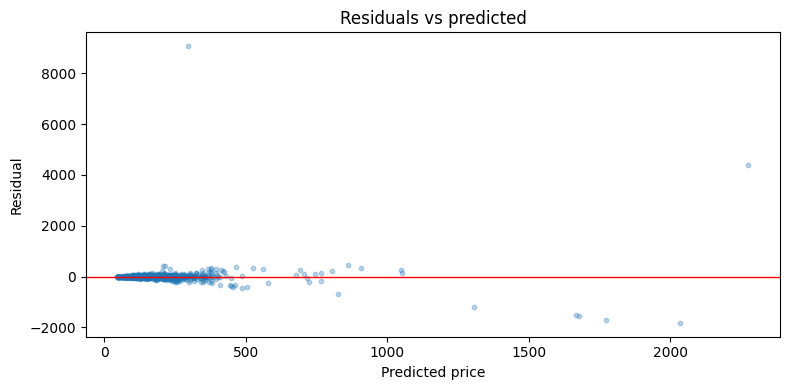

In [3]:
# Residual plot
residuals = y_test - pred
plt.figure(figsize=(8,4))
plt.scatter(pred, residuals, alpha=0.3, s=10)
plt.axhline(0, color='red', linewidth=1)
plt.xlabel('Predicted price')
plt.ylabel('Residual')
plt.title('Residuals vs predicted')
plt.tight_layout()
plt.savefig('../reports/figures/residuals.png', dpi=150)
plt.show()

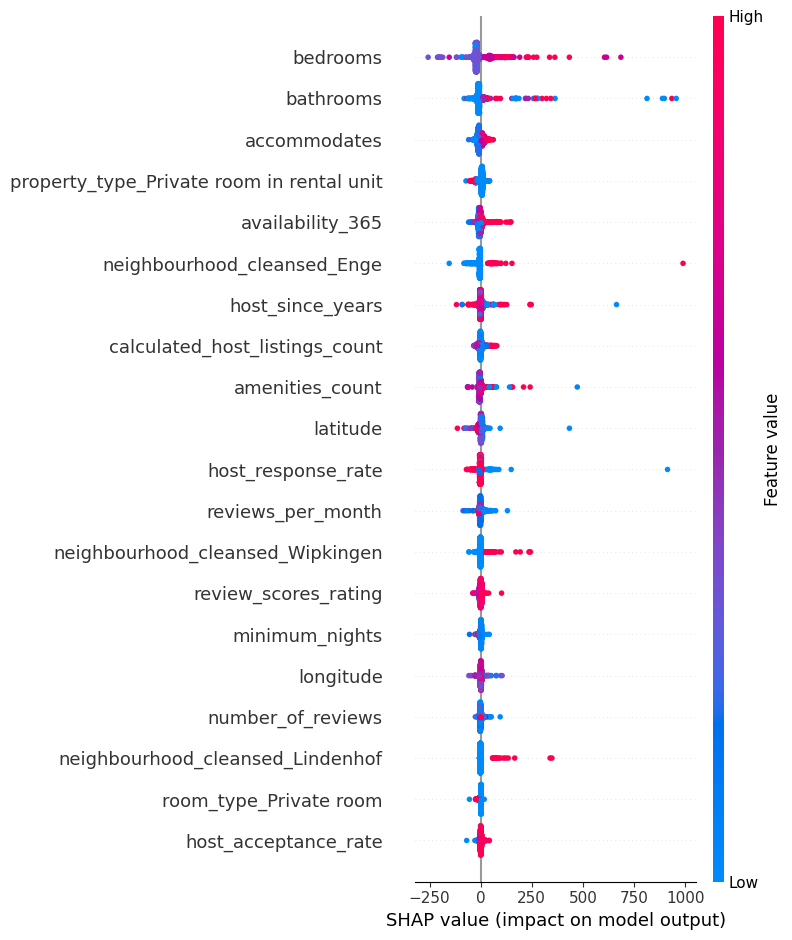

In [4]:
# SHAP
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

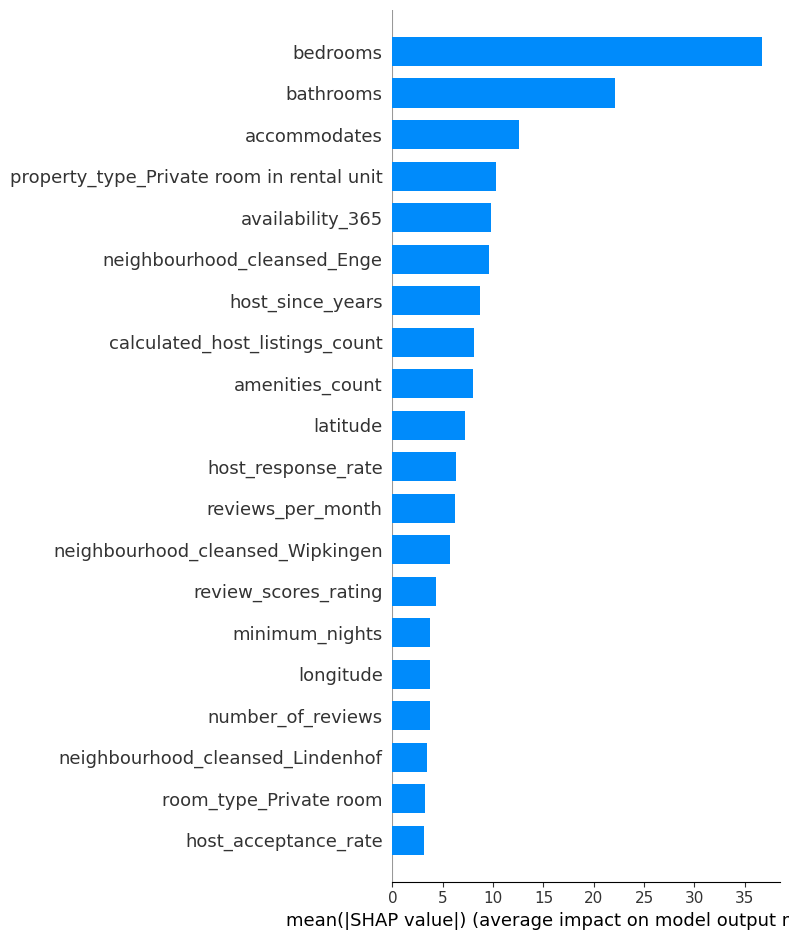

In [5]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## AI Reflection
- What worked well?
- What are the model limitations?
- What biases might exist in the data?
- What would you improve with more time?